Title : Decision Tree Classification <br>
Author : raghav | Github : @raghavtwenty <br>
Date Created : April 19, 2023 | Last Updated : April 19, 2023 <br>
Language : Python | Version : 3.11.2

AIM :<br>
Build a Decision Tree using entropy and Information Gain looking into combination
of outlook , humidity and wind and the target is Play.

ALGORITHM:
1. Start the program.
2. Import the dataset and the required packages
3. Clean the dataset.
4. Calculate the entropy for the root node.
5. Calculate the information gain.
6. Display the results and stop the program.

Importing the required libraries.

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
from _8_ import DecisionTree

Import the dataset.

In [2]:
DF = pd.read_csv('/Users/raghav/Documents/Programs/python/ml/datasets/_8_ML-sem4-DTree-cricket-dataset - Sheet1.csv')

View the dataset.

In [3]:
DF.drop('Day', inplace=True, axis=1) # Drop Days column
DF

,Outlook,Humidity,Wind,Play
0,Sunny,High,Weak,No
1,Sunny,High,Strong,NO
2,Overcast,High,Weak,Yes
3,Rain,High,Weak,yes
4,Rain,Normal,Weak,yes
5,Rain,Normal,Strong,No
6,Overcast,Normal,Strong,yes
7,Sunny,High,Weak,no
8,Sunny,Normal,Weak,yes
9,Rain,Normal,Weak,yes


Convert the contents to lowercase.

In [4]:
for i in DF:
    DF[i] = DF[i].str.lower()

In [5]:
DF

,Outlook,Humidity,Wind,Play
0,sunny,high,weak,no
1,sunny,high,strong,no
2,overcast,high,weak,yes
3,rain,high,weak,yes
4,rain,normal,weak,yes
5,rain,normal,strong,no
6,overcast,normal,strong,yes
7,sunny,high,weak,no
8,sunny,normal,weak,yes
9,rain,normal,weak,yes


Convert the strings to integer.

In [6]:
Label_Encoder = LabelEncoder()

Col_Titles = DF.columns.values

for Index, Item in enumerate(DF):
    DF[Col_Titles[Index]] = Label_Encoder.fit_transform(DF[Item])

In [7]:
DF

,Outlook,Humidity,Wind,Play
0,2,0,1,0
1,2,0,0,0
2,0,0,1,1
3,1,0,1,1
4,1,1,1,1
5,1,1,0,0
6,0,1,0,1
7,2,0,1,0
8,2,1,1,1
9,1,1,1,1


Assign X and Y

In [8]:
X = DF[['Outlook','Humidity','Wind']].values
Y = DF['Play'].values

In [9]:
DTC = DecisionTree()
DTC.fit(X,Y)

In [10]:
# Get the input from the user
Inpt_Outlook = int(input("Enter the Outlook condition [0-Overcast, 1-Rainy, 2-Sunny]: "))
Inpt_Hum = int(input("Enter the Humidity condition [0-High, 1-Normal]: "))
Inpt_Wind = int(input("Enter the wind condition [0-Strong, 1-Week]: "))

# Predict the output with the model
Res = DTC.predict([[Inpt_Outlook, Inpt_Hum, Inpt_Wind]])

# Final show
if Res == 0:
    print("Not Recomended to play.")
elif Res == 1:
    print("You can play.")

You can play.


[CHECK WITH INBUILT LIBRARY]

In [11]:
# Imports
from sklearn.tree import DecisionTreeClassifier  # Import Decision Tree Classifier

Build decision tree using builtin library

In [12]:
X = DF[['Outlook','Humidity','Wind']]
Y = DF[['Play']]
DTC = DecisionTreeClassifier(criterion='entropy')
DTC = DTC.fit(X, Y)

[Text(0.4444444444444444, 0.9, 'x[0] <= 0.5\nentropy = 0.94\nsamples = 14\nvalue = [5, 9]'), Text(0.3333333333333333, 0.7, 'entropy = 0.0\nsamples = 4\nvalue = [0, 4]'), Text(0.5555555555555556, 0.7, 'x[1] <= 0.5\nentropy = 1.0\nsamples = 10\nvalue = [5, 5]'), Text(0.3333333333333333, 0.5, 'x[0] <= 1.5\nentropy = 0.722\nsamples = 5\nvalue = [4, 1]'), Text(0.2222222222222222, 0.3, 'x[2] <= 0.5\nentropy = 1.0\nsamples = 2\nvalue = [1, 1]'), Text(0.1111111111111111, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'), Text(0.3333333333333333, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'), Text(0.4444444444444444, 0.3, 'entropy = 0.0\nsamples = 3\nvalue = [3, 0]'), Text(0.7777777777777778, 0.5, 'x[2] <= 0.5\nentropy = 0.722\nsamples = 5\nvalue = [1, 4]'), Text(0.6666666666666666, 0.3, 'x[0] <= 1.5\nentropy = 1.0\nsamples = 2\nvalue = [1, 1]'), Text(0.5555555555555556, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'), Text(0.7777777777777778, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = 

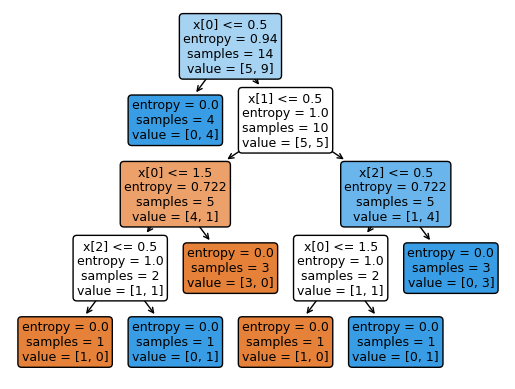

In [13]:
feature_names = DF.columns[:3]
target_names = DF['Play'].unique().tolist()

# Graphical view
print(tree.plot_tree(DTC, filled=True, rounded=True))

Viewing the Decision Tree

In [14]:
# Text View
print(tree.export_text(DTC))

|--- feature_0 <= 0.50
|   |--- class: 1
|--- feature_0 >  0.50
|   |--- feature_1 <= 0.50
|   |   |--- feature_0 <= 1.50
|   |   |   |--- feature_2 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_2 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- feature_0 >  1.50
|   |   |   |--- class: 0
|   |--- feature_1 >  0.50
|   |   |--- feature_2 <= 0.50
|   |   |   |--- feature_0 <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_0 >  1.50
|   |   |   |   |--- class: 1
|   |   |--- feature_2 >  0.50
|   |   |   |--- class: 1



INFERENCE : <br>
For the given input Outlook condition as Overcast, Humidity condition as Normal and the Wind condition as week the decision tree classification model results that, It is the good time to play cricket.